In [2]:
import pandas as pd

train = pd.read_csv("train.csv", encoding='latin-1', on_bad_lines='skip')
test = pd.read_csv("test.csv", encoding='latin-1', on_bad_lines='skip')

print(train.columns)

X_train = train.iloc[:, 0]
y_train = train.iloc[:, 1]

X_test = test.iloc[:, 0]
y_test = test.iloc[:, 1]

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)

from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)

from sklearn.metrics import precision_score, recall_score

print("Naive Bayes:")
print("Precision:", precision_score(y_test, nb_pred, average='macro'))
print("Recall:", recall_score(y_test, nb_pred, average='macro'))

print("\nLogistic Regression:")
print("Precision:", precision_score(y_test, lr_pred, average='macro'))
print("Recall:", recall_score(y_test, lr_pred, average='macro'))

print("\nSVM:")
print("Precision:", precision_score(y_test, svm_pred, average='macro'))
print("Recall:", recall_score(y_test, svm_pred, average='macro'))

Index(['tweet', 'label'], dtype='str')
Naive Bayes:
Precision: 0.48333333333333334
Recall: 0.5873015873015873

Logistic Regression:
Precision: 0.5
Recall: 0.611111111111111

SVM:
Precision: 0.4777777777777778
Recall: 0.5158730158730158


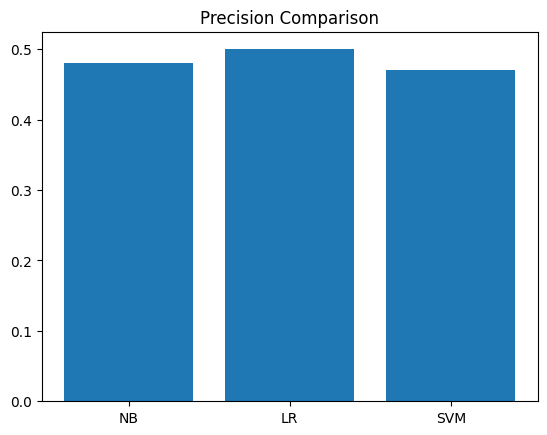

In [3]:
import matplotlib.pyplot as plt

models = ["NB", "LR", "SVM"]
precision = [0.48, 0.50, 0.47]
recall = [0.58, 0.61, 0.51]

plt.bar(models, precision)
plt.title("Precision Comparison")
plt.show()